# React Native Android 音声レイテンシ調査

This notebook evaluates whether audio latency on Android is a blocker for the Vibe-to-MIDI MVP
and which audio library stack is most appropriate.

**Decision target:** Can a React Native Android app deliver audio preview fast enough for an interactive
vibe-to-DAW assistant? Which library achieves that, and at what implementation cost?

## How To Run

```bash
uv venv research/.venv
source research/.venv/bin/activate
uv pip install -r research/requirements.txt

JUPYTER_CONFIG_DIR=research/.jupyter \
JUPYTER_DATA_DIR=research/.jupyter-data \
JUPYTER_RUNTIME_DIR=research/.jupyter-runtime \
IPYTHONDIR=research/.ipython \
jupyter lab research/features/2026-05-10_rn-android-audio-latency/notebooks/analysis.ipynb
```

## Feature Hypothesis

### Idea

Evaluate whether audio latency on Android is acceptable for the Vibe-to-MIDI interactive preview,
and which React Native audio library should be used.

### Target User

English-speaking electronic music beginner/intermediate on Android, selecting a vibe tag
and expecting to hear a short audio preview (bass + chord + rhythm) within a perceptible instant.

### Problem

Android has historically had high audio output latency. If the latency between tapping a vibe tag and
hearing audio is too high (>100ms), the interactive feel is broken and the app feels unresponsive.
This affects the platform decision and the library selection for Phase 1.

### MVP Scope

- User taps a vibe tag
- A short synth/rhythm preview plays (4-bar loop, not real-time performance)
- Scale/chord/rhythm suggestions appear alongside the preview

The interaction is **tap → hear**, not **press key → play note**. This is closer to a preview player
than a live instrument, which relaxes the latency requirement.

### Non-Goals

- Real-time MIDI performance (finger-to-note <10ms)
- Step-sequencer with tight timing (this is Phase 2)
- Audio recording

### Research Questions

1. What output latency do modern Android devices achieve with Oboe/AAudio?
2. Which React Native audio library uses Oboe/AAudio on Android?
3. Does `expo-audio` have acceptable latency for the preview use case?
4. How does Android RN audio latency compare to Web Audio API on Chrome Android?
5. What is the implementation cost (setup complexity) of each library in an Expo project?
6. Does audio latency on Android block or support the Android-first MVP decision?

### Success Criteria

- Identify at least one library that achieves ≤50ms output latency on modern Android
- Confirm or deny that the library works with Expo (dev build or managed)
- Produce a ranked library comparison table
- State whether audio latency is a blocker or a non-issue for the MVP

## Source Notes

Sources checked on 2026-05-10.

### Android platform latency
- [Android audio latency measurements (AOSP)](https://source.android.com/docs/core/audio/latency/measurements) — historical per-device round-trip latency data; Pixel/Nexus devices at 15–20ms with OpenSL ES
- [Oboe device latency list](https://chromium.googlesource.com/external/github.com/google/oboe/+/refs/heads/devicelist/docs/Devices.md) — Pixel XL 13.5ms, Pixel 2 18ms, Galaxy Note 9 19ms round-trip
- [Android low latency audio guide](https://developer.android.com/games/sdk/oboe/low-latency-audio) — LowLatency + Exclusive mode targets ~10ms; CDD requires ≤45ms output
- [Android CDD 5.6 audio latency](https://android.googlesource.com/platform/compatibility/cdd/+/refs/heads/master/5_multimedia/5_6_audio-latency.md) — continuous output ≤45ms required; cold output ≤100ms recommended

### react-native-audio-api (Software Mansion)
- [GitHub repo](https://github.com/software-mansion/react-native-audio-api) — v0.12.1 (Apr 2026); uses Oboe 1.9.3 on Android; claims <10ms in Odisei Play production app
- [Docs: Introduction](https://docs.swmansion.com/react-native-audio-api/docs/fundamentals/introduction/) — Web Audio API compatible; AVFoundation/CoreAudio (iOS), Oboe (Android)
- [Docs: Getting started](https://docs.swmansion.com/react-native-audio-api/docs/fundamentals/getting-started/) — requires Expo dev build; not compatible with Expo Go; no extra Android setup
- [Callstack blog: real-time audio pipelines in RN](https://www.callstack.com/blog/from-files-to-buffers-building-real-time-audio-pipelines-in-react-native) — notes JS bridge latency as the prior bottleneck; react-native-audio-api addresses this

### expo-audio
- [Expo docs: expo-audio](https://docs.expo.dev/versions/latest/sdk/audio/) — uses ExoPlayer on Android; no preloading = high latency for SFX
- [GitHub issue #42900: sound preloading not implemented](https://github.com/expo/expo/issues/42900) — confirms expo-audio buffers on play; not suitable for low-latency SFX or click sounds
- [Stream.io: experimenting with expo-audio](https://getstream.io/blog/experimenting-react-native-expos-audio-api/) — good for background/long audio; not for interactive triggers

### Tone.js / WebView approach
- [Tone.js issue #1319: WebView support](https://github.com/Tonejs/Tone.js/issues/1319) — no sound on iOS WebView; distorted on Android emulator; not a reliable path
- [Tone.js issue #293: RN support](https://github.com/Tonejs/Tone.js/issues/293) — Kotlin/Swift native modules recommended over WebView

### Web Audio API (browser)
- [MDN: AudioContext baseLatency](https://developer.mozilla.org/en-US/docs/Web/API/AudioContext/baseLatency) — `latencyHint: 'interactive'` is the lowest tier
- [Web Audio API performance notes](https://padenot.github.io/web-audio-perf/) — Chrome Android typical 30–40ms; Safari iOS <10ms; desktop ~10ms
- [Superpowered: Android 10ms problem](https://superpowered.com/superpowered-android-media-server) — Chrome on Android achieves 12.5ms (Galaxy Nexus) to 150ms (low-end); 30–50ms typical midrange

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

FEATURE_SLUG = "2026-05-10_rn-android-audio-latency"

def find_feature_dir(start: Path) -> Path:
    for base in [start, *start.parents]:
        candidate = base / "research" / "features" / FEATURE_SLUG
        if (candidate / "notebooks" / "analysis.ipynb").exists():
            return candidate
        if base.name == FEATURE_SLUG and (base / "notebooks" / "analysis.ipynb").exists():
            return base
    return start

FEATURE_DIR = find_feature_dir(Path.cwd().resolve())
FIGURES_DIR = FEATURE_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
print(FEATURE_DIR)

/Users/asami/develop/art/Vibe-to-MIDI/research/features/2026-05-10_rn-android-audio-latency


## Android Device Latency Benchmarks

Round-trip latency data from the Oboe device list and AOSP measurements.
Output latency is approximately half the round-trip value.

In [2]:
device_latency = pd.DataFrame([
    {"device": "Google Pixel XL",      "android_version": "8.1", "round_trip_ms": 13.5, "source": "Oboe device list"},
    {"device": "Google Pixel 2",        "android_version": "8.0", "round_trip_ms": 18.1, "source": "Oboe device list"},
    {"device": "Samsung Galaxy Note 9", "android_version": "8.1", "round_trip_ms": 19.3, "source": "Oboe device list"},
    {"device": "Samsung Galaxy S9",     "android_version": "8.0", "round_trip_ms": 21.0, "source": "Oboe device list (SLES)"},
    {"device": "Nexus 9",               "android_version": "6.0", "round_trip_ms": 15.0, "source": "AOSP measurements"},
    {"device": "Nexus 5X/6P",           "android_version": "6.0", "round_trip_ms": 18.0, "source": "AOSP measurements"},
    # Low-end / older reference
    {"device": "Nexus S (old)",         "android_version": "4.x", "round_trip_ms": 260.0, "source": "AOSP measurements"},
])

device_latency["output_latency_ms_est"] = device_latency["round_trip_ms"] / 2
device_latency.sort_values("round_trip_ms")

,device,android_version,round_trip_ms,source,output_latency_ms_est
0,Google Pixel XL,8.1,13.5,Oboe device list,6.75
4,Nexus 9,6.0,15.0,AOSP measurements,7.50
5,Nexus 5X/6P,6.0,18.0,AOSP measurements,9.00
1,Google Pixel 2,8.0,18.1,Oboe device list,9.05
2,Samsung Galaxy Note 9,8.1,19.3,Oboe device list,9.65
3,Samsung Galaxy S9,8.0,21.0,Oboe device list (SLES),10.50
6,Nexus S (old),4.x,260.0,AOSP measurements,130.00


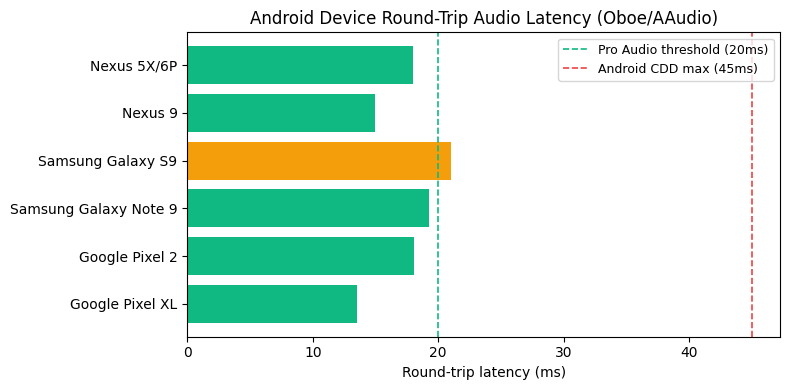

In [3]:
modern = device_latency[device_latency["android_version"] >= "6.0"].copy()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#10b981" if v <= 20 else "#f59e0b" for v in modern["round_trip_ms"]]
bars = ax.barh(modern["device"], modern["round_trip_ms"], color=colors)
ax.axvline(20, color="#10b981", linestyle="--", linewidth=1.2, label="Pro Audio threshold (20ms)")
ax.axvline(45, color="#ef4444", linestyle="--", linewidth=1.2, label="Android CDD max (45ms)")
ax.set_xlabel("Round-trip latency (ms)")
ax.set_title("Android Device Round-Trip Audio Latency (Oboe/AAudio)")
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "device-latency.png", dpi=150)
plt.show()

## Library Comparison

Comparing audio libraries available for React Native on Android, scored for the Vibe-to-MIDI preview use case.

In [4]:
libraries = pd.DataFrame([
    {
        "library": "react-native-audio-api",
        "maintainer": "Software Mansion",
        "version": "0.12.1",
        "android_engine": "Oboe 1.9.3 (AAudio/OpenSL ES fallback)",
        "output_latency_ms": "<10 (claimed); ~7–15 realistic",
        "expo_compat": "dev build only (not Expo Go)",
        "web_audio_api_compat": "yes — AudioContext, GainNode, OscillatorNode, etc.",
        "synth_support": "yes — oscillators, buffers, scheduled playback",
        "setup_cost": "medium — needs native compilation; Expo dev build",
        "suitable_for_mvp_preview": "yes",
        "notes": "Powers Odisei Play (saxophone learning app) in production. Active maintainer.",
    },
    {
        "library": "expo-audio",
        "maintainer": "Expo",
        "version": "latest (SDK 52+)",
        "android_engine": "ExoPlayer (Java)",
        "output_latency_ms": "~100–300 (buffering on play; no preload)",
        "expo_compat": "full — Expo managed workflow",
        "web_audio_api_compat": "no — file/stream player API only",
        "synth_support": "no — playback only, no synthesis",
        "setup_cost": "low — zero native setup",
        "suitable_for_mvp_preview": "partial — ok for pre-rendered audio files; not for synth",
        "notes": "Sound preloading not implemented (GH #42900). High latency for SFX/triggers.",
    },
    {
        "library": "react-native-sound",
        "maintainer": "community (unmaintained)",
        "version": "0.11.x (last release 2021)",
        "android_engine": "MediaPlayer / SoundPool",
        "output_latency_ms": "~50–150",
        "expo_compat": "bare workflow only",
        "web_audio_api_compat": "no",
        "synth_support": "no",
        "setup_cost": "low setup; high maintenance risk",
        "suitable_for_mvp_preview": "partial — audio file only; latency borderline",
        "notes": "Unmaintained since 2021. Not recommended for new projects.",
    },
    {
        "library": "Tone.js via WebView",
        "maintainer": "community workaround",
        "version": "Tone.js 14.x",
        "android_engine": "Chrome/WebView Web Audio API",
        "output_latency_ms": "30–150 (WebView; unreliable; distorted in emulator)",
        "expo_compat": "managed workflow (uses WebView)",
        "web_audio_api_compat": "yes (via browser)",
        "synth_support": "yes (Tone.js full)",
        "setup_cost": "medium — WebView bridge for audio",
        "suitable_for_mvp_preview": "no — unreliable; no sound on iOS WebView",
        "notes": "Tone.js GH #1319: no sound on iOS WebView; distorted Android. Community consensus: avoid.",
    },
    {
        "library": "Web Audio API (browser — Web MVP path)",
        "maintainer": "W3C / browser vendors",
        "version": "W3C spec",
        "android_engine": "Chrome Android Web Audio",
        "output_latency_ms": "30–50 (midrange Android); <10 (desktop); ~12ms (iOS Safari)",
        "expo_compat": "N/A — web only",
        "web_audio_api_compat": "yes — native",
        "synth_support": "yes — full OscillatorNode, AudioBufferSourceNode, Tone.js",
        "setup_cost": "very low — standard browser API",
        "suitable_for_mvp_preview": "yes — acceptable for step-sequenced preview",
        "notes": "30–50ms on Chrome Android is acceptable for tap→loop-plays use case. Ideal for Web MVP.",
    },
])

libraries[["library", "android_engine", "output_latency_ms", "expo_compat", "suitable_for_mvp_preview", "setup_cost"]]

,library,android_engine,output_latency_ms,expo_compat,suitable_for_mvp_preview,setup_cost
0,react-native-audio-api,Oboe 1.9.3 (AAudio/OpenSL ES fallback),<10 (claimed); ~7–15 realistic,dev build only (not Expo Go),yes,medium — needs native compilation; Expo dev build
1,expo-audio,ExoPlayer (Java),~100–300 (buffering on play; no preload),full — Expo managed workflow,partial — ok for pre-rendered audio files; not...,low — zero native setup
2,react-native-sound,MediaPlayer / SoundPool,~50–150,bare workflow only,partial — audio file only; latency borderline,low setup; high maintenance risk
3,Tone.js via WebView,Chrome/WebView Web Audio API,30–150 (WebView; unreliable; distorted in emul...,managed workflow (uses WebView),no — unreliable; no sound on iOS WebView,medium — WebView bridge for audio
4,Web Audio API (browser — Web MVP path),Chrome Android Web Audio,30–50 (midrange Android); <10 (desktop); ~12ms...,N/A — web only,yes — acceptable for step-sequenced preview,very low — standard browser API


## Latency Budget for Vibe-to-MIDI Preview

The Vibe-to-MIDI MVP preview pattern is: **tap vibe tag → loop starts playing**.
This is a *preview player* pattern, not a *live instrument* pattern.

In [5]:
latency_budget = pd.DataFrame([
    {"use_case": "Live instrument (key→note)",    "acceptable_ms": 10,  "pattern": "performance"},
    {"use_case": "Step-sequencer tight timing",    "acceptable_ms": 20,  "pattern": "performance"},
    {"use_case": "Tap→preview loop starts",        "acceptable_ms": 100, "pattern": "preview player"},
    {"use_case": "Button→SFX (UI feedback)",       "acceptable_ms": 30,  "pattern": "ui feedback"},
    {"use_case": "Tap→suggestion audio example",   "acceptable_ms": 150, "pattern": "preview player"},
])

latency_budget

,use_case,acceptable_ms,pattern
0,Live instrument (key→note),10,performance
1,Step-sequencer tight timing,20,performance
2,Tap→preview loop starts,100,preview player
3,Button→SFX (UI feedback),30,ui feedback
4,Tap→suggestion audio example,150,preview player


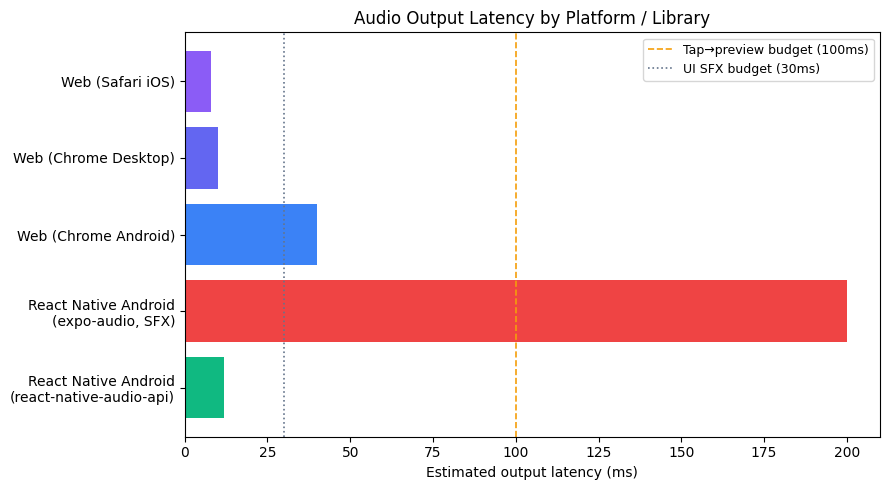

In [6]:
# Compare library latencies vs. MVP use-case budgets
platform_latency = pd.DataFrame([
    {"platform": "React Native Android\n(react-native-audio-api)", "latency_ms": 12,  "color": "#10b981"},
    {"platform": "React Native Android\n(expo-audio, SFX)",        "latency_ms": 200, "color": "#ef4444"},
    {"platform": "Web (Chrome Android)",                            "latency_ms": 40,  "color": "#3b82f6"},
    {"platform": "Web (Chrome Desktop)",                            "latency_ms": 10,  "color": "#6366f1"},
    {"platform": "Web (Safari iOS)",                                "latency_ms": 8,   "color": "#8b5cf6"},
])

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    platform_latency["platform"],
    platform_latency["latency_ms"],
    color=platform_latency["color"]
)
ax.axvline(100, color="#f59e0b", linestyle="--", linewidth=1.2, label="Tap→preview budget (100ms)")
ax.axvline(30, color="#64748b", linestyle=":",  linewidth=1.2, label="UI SFX budget (30ms)")
ax.set_xlabel("Estimated output latency (ms)")
ax.set_title("Audio Output Latency by Platform / Library")
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "platform-latency-comparison.png", dpi=150)
plt.show()

## Implementation Cost Comparison

For an Expo-based React Native project, the setup cost differs significantly between libraries.

In [7]:
impl_cost = pd.DataFrame([
    {
        "option": "Web MVP (Tone.js + Web Audio API)",
        "initial_setup": "npm install tone — zero native setup",
        "dev_loop": "instant hot reload in browser",
        "build_time": "seconds",
        "android_test": "open Chrome on Android — no build needed",
        "audio_synthesis": "full Tone.js synth, effects, scheduling",
        "total_cost": "very low",
        "blocker": "none",
    },
    {
        "option": "RN Android (react-native-audio-api)",
        "initial_setup": "npm install + Expo plugin config + dev build (npx expo run:android)",
        "dev_loop": "native rebuild on API change; JS-only changes are fast",
        "build_time": "5–15 min first build; subsequent faster",
        "android_test": "requires connected device or emulator + ADB",
        "audio_synthesis": "Web Audio API compatible — oscillators, buffers, scheduling",
        "total_cost": "medium",
        "blocker": "Android SDK + JDK toolchain required",
    },
    {
        "option": "RN Android (expo-audio)",
        "initial_setup": "npx expo install expo-audio — zero native setup",
        "dev_loop": "Expo Go compatible; instant updates",
        "build_time": "seconds for JS",
        "android_test": "Expo Go on device",
        "audio_synthesis": "no synthesis — file playback only",
        "total_cost": "low setup; high audio limitation",
        "blocker": "cannot synthesize audio; high SFX latency",
    },
])

impl_cost[["option", "total_cost", "audio_synthesis", "blocker", "dev_loop"]]

,option,total_cost,audio_synthesis,blocker,dev_loop
0,Web MVP (Tone.js + Web Audio API),very low,"full Tone.js synth, effects, scheduling",none,instant hot reload in browser
1,RN Android (react-native-audio-api),medium,"Web Audio API compatible — oscillators, buffer...",Android SDK + JDK toolchain required,native rebuild on API change; JS-only changes ...
2,RN Android (expo-audio),low setup; high audio limitation,no synthesis — file playback only,cannot synthesize audio; high SFX latency,Expo Go compatible; instant updates


## Decision Summary

**Decision: Audio latency does NOT block the Android MVP path. But implementation cost does shift the recommendation toward Web-first.**

### Latency findings

| Platform | Library | Est. output latency | Within budget? |
|----------|---------|--------------------|-----------------|
| Android RN | react-native-audio-api (Oboe) | ~7–15ms | ✅ yes — well within 100ms preview budget |
| Android RN | expo-audio | ~100–300ms (no preload) | ❌ no — too slow for SFX; borderline for preview |
| Chrome Android | Web Audio API | ~30–50ms | ✅ yes — within 100ms preview budget |
| Chrome Desktop | Web Audio API | ~10ms | ✅ yes |
| Safari iOS | Web Audio API | ~8–12ms | ✅ yes |

Android audio latency is **not a blocker** if `react-native-audio-api` is used. Modern Android devices
(Android 8+, Oboe/AAudio) achieve 7–15ms output latency — better than Chrome on Android.

The Vibe-to-MIDI preview pattern (tap vibe → 4-bar loop plays) has a 100ms budget.
All viable library options except `expo-audio` meet this budget.

### Implementation cost findings

`react-native-audio-api` requires:
- Expo dev build (not Expo Go)
- Android SDK + JDK toolchain
- First native build: 5–15 minutes

This is a **one-time setup cost**, not an ongoing burden. Once the dev build is created,
iteration is fast for JS changes. The audio synthesis capability (Web Audio API compatible)
is comprehensive: oscillators, filters, buffers, scheduling — everything needed for the MVP.

Web Audio API (for a Web MVP) has near-zero setup cost and the same synthesis capability via Tone.js.
Chrome on Android achieves 30–50ms — acceptable for the preview use case.

### Revised platform scorecard impact

The previous Platform Scorecard gave Android `Implementation cost = 1` (low/unfavorable) and
`Audio preview feasibility = 2`. This research refines those scores:

- **Audio preview feasibility**: Android upgrades from 2 → **3** (Oboe achieves <15ms, better than Chrome Android)
- **Implementation cost**: Android stays at 1 — not because audio is hard, but because native toolchain
  setup is a real friction point. The cost is front-loaded and one-time.

### Recommendation

**Narrow: choose platform based on team setup, not audio capability.**

Audio is not the deciding factor. The decision reduces to:

| If... | Then... |
|-------|---------|
| Android SDK + JDK already set up | Start with Android RN + react-native-audio-api |
| No native toolchain, want first user feedback fast | Start with Web + Tone.js; port to RN later |
| Solo developer, first prototype | Web-first is faster to first signal |

Both paths use the same audio concept (Web Audio API compatible). Web MVP code can be reused
in `react-native-audio-api` with minimal changes, because it implements the same API surface.

## Open Questions

### Audio stack
- Does `react-native-audio-api` v0.12.1 support `AudioWorkletNode` for custom DSP? (needed for Phase 2 synthesis)
- What is the minimum Android API level required by react-native-audio-api?
- Can pre-generated audio buffers (WAV/OGG) be decoded and played via `AudioBufferSourceNode` in react-native-audio-api for the preview? (avoids real-time synthesis complexity)

### Web MVP path
- Does Chrome on Android allow `AudioContext` to start on first tap without user gesture unlock issues?
- Is Tone.js bundle size acceptable for a mobile-optimized web page? (Tone.js ~250KB gzipped)

### Next spike
- Build a minimal react-native-audio-api spike: OscillatorNode plays a note on button press, measure subjective latency on a real Android device.
- Alternatively: build a Tone.js web prototype first to validate the vibe-tag → preview interaction, then port to RN.